# CNN - EfficientNetB0
Bài toán phân loại ảnh chim (150 lớp) sử dụng EfficientNetB0 với Transfer Learning.

In [8]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from google.colab import drive
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## Load Dataset

In [9]:
drive.mount('/content/drive')

PATH_ORIGINAL_ZIP  = '/content/drive/MyDrive/CS231/original_dataset.zip'
EXTRACT_DIR_ORIG   = '/content/original_dataset'

def extract_zip(zip_path, extract_path):
    if not os.path.exists(zip_path):
        print(f'LOI: Khong tim thay file {zip_path}.')
        return
    if not os.path.exists(extract_path):
        os.makedirs(extract_path, exist_ok=True)
        print(f'Dang giai nen {zip_path}...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(extract_path)
        print(f'Giai nen xong: {extract_path}')
    else:
        print(f'Thu muc da ton tai: {extract_path}')

extract_zip(PATH_ORIGINAL_ZIP, EXTRACT_DIR_ORIG)

ORIG_PATH = {
    'train': os.path.join(EXTRACT_DIR_ORIG, 'train'),
    'val':   os.path.join(EXTRACT_DIR_ORIG, 'val'),
    'test':  os.path.join(EXTRACT_DIR_ORIG, 'test')
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dang giai nen /content/drive/MyDrive/CS231/original_dataset.zip...
Giai nen xong: /content/original_dataset


## Build Model - EfficientNetB0

In [10]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import (Input, GlobalAveragePooling2D,
                                     Dense, Dropout, BatchNormalization)
from tensorflow.keras.models import Model

def build_efficientnetb0(input_shape=(224, 224, 3), num_classes=150):

    input_tensor = Input(shape=input_shape)

    backbone = EfficientNetB0(include_top=False,
                              weights='imagenet',
                              input_tensor=input_tensor)

    backbone.trainable = False

    x = backbone.output

    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    return Model(inputs=input_tensor, outputs=output)

model = build_efficientnetb0(input_shape=(224, 224, 3), num_classes=150)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,246,841 (16.20 MB)

 Trainable params: 194,710 (760.59 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Hàm Đánh Giá và Vẽ Biểu Đồ

In [11]:
def evaluate_and_plot(model, test_generator, title="Model Evaluation"):
    test_generator.reset()
    Y_pred = model.predict(test_generator)
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = test_generator.classes

    acc = accuracy_score(y_true, y_pred)
    pre, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

    print(f"\n--- {title} ---")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {pre:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

def plot_training_history(history, title="EfficientNetB0"):
    acc     = history.history.get('accuracy', history.history.get('acc'))
    val_acc = history.history.get('val_accuracy', history.history.get('val_acc'))
    loss     = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc,     'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f'Accuracy - {title}')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss,     'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title(f'Loss - {title}')
    plt.xlabel('Epochs'); plt.ylabel('Loss')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout(); plt.show()

def plot_sample_predictions(model, test_generator, num_samples=5):
    test_generator.reset()
    Y_pred = model.predict(test_generator)
    y_pred = np.argmax(Y_pred, axis=1)
    y_true = test_generator.classes
    class_names = list(test_generator.class_indices.keys())

    correct_idx   = np.where(y_pred == y_true)[0]
    incorrect_idx = np.where(y_pred != y_true)[0]

    def draw_grid(indices, status_title):
        plt.figure(figsize=(20, 5))
        plt.suptitle(f"Ví dụ dự đoán {status_title}", fontsize=16, fontweight='bold')
        selected = np.random.choice(indices, min(num_samples, len(indices)), replace=False)
        for i, idx in enumerate(selected):
            batch_idx       = idx // test_generator.batch_size
            img_idx_in_batch = idx % test_generator.batch_size
            imgs, _ = test_generator[batch_idx]
            img = imgs[img_idx_in_batch]
            plt.subplot(1, num_samples, i + 1)
            plt.imshow(img)
            true_label = class_names[y_true[idx]]
            pred_label = class_names[y_pred[idx]]
            color = 'green' if status_title == "ĐÚNG" else 'red'
            plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)
            plt.axis('off')
        plt.tight_layout(); plt.show()

    if len(correct_idx) > 0:   draw_grid(correct_idx,   "ĐÚNG")
    if len(incorrect_idx) > 0: draw_grid(incorrect_idx, "SAI")

## Training - Giai Đoạn 1 (Backbone Frozen)

In [12]:
datagen = ImageDataGenerator()

train_gen = datagen.flow_from_directory(ORIG_PATH['train'], target_size=(224, 224),
                                        batch_size=32, class_mode='categorical')
val_gen   = datagen.flow_from_directory(ORIG_PATH['val'],   target_size=(224, 224),
                                        batch_size=32, class_mode='categorical')
test_gen  = datagen.flow_from_directory(ORIG_PATH['test'],  target_size=(224, 224),
                                        batch_size=32, class_mode='categorical', shuffle=False)

early_stop = EarlyStopping(monitor='val_loss', patience=2,
                            restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                patience=2, min_lr=1e-6, verbose=1)
callbacks_list = [early_stop, reduce_lr]

model_eff = build_efficientnetb0()
model_eff.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print("\n[EfficientNetB0] Training - Giai đoạn 1 (Backbone Frozen)...")
history_stage1 = model_eff.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_list
)

Found 20080 images belonging to 150 classes.
Found 4248 images belonging to 150 classes.
Found 4468 images belonging to 150 classes.

[EfficientNetB0] Training - Giai đoạn 1 (Backbone Frozen)...
Epoch 1/10
628/628 ━━━━━━━━━━━━━━━━━━━━ 115s 131ms/step - accuracy: 0.7110 - loss: 2.0827 - val_accuracy: 0.9407 - val_loss: 1.2844 - learning_rate: 0.0010
Epoch 2/10
628/628 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.8968 - loss: 1.4068 - val_accuracy: 0.9482 - val_loss: 1.2261 - learning_rate: 0.0010
Epoch 3/10
628/628 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9273 - loss: 1.3047 - val_accuracy: 0.9534 - val_loss: 1.1852 - learning_rate: 0.0010
Epoch 4/10
628/628 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9397 - loss: 1.2467 - val_accuracy: 0.9541 - val_loss: 1.1645 - learning_rate: 0.0010
Epoch 5/10
628/628 ━━━━━━━━━━━━━━━━━━━━ 43s 69ms/step - accuracy: 0.9496 - loss: 1.2093 - val_accuracy: 0.9562 - val_loss: 1.1512 - learning_rate: 0.0010
Epoch 6/10
628/628 ━━━━━━━━━━━━━━

### Kết Quả Giai Đoạn 1

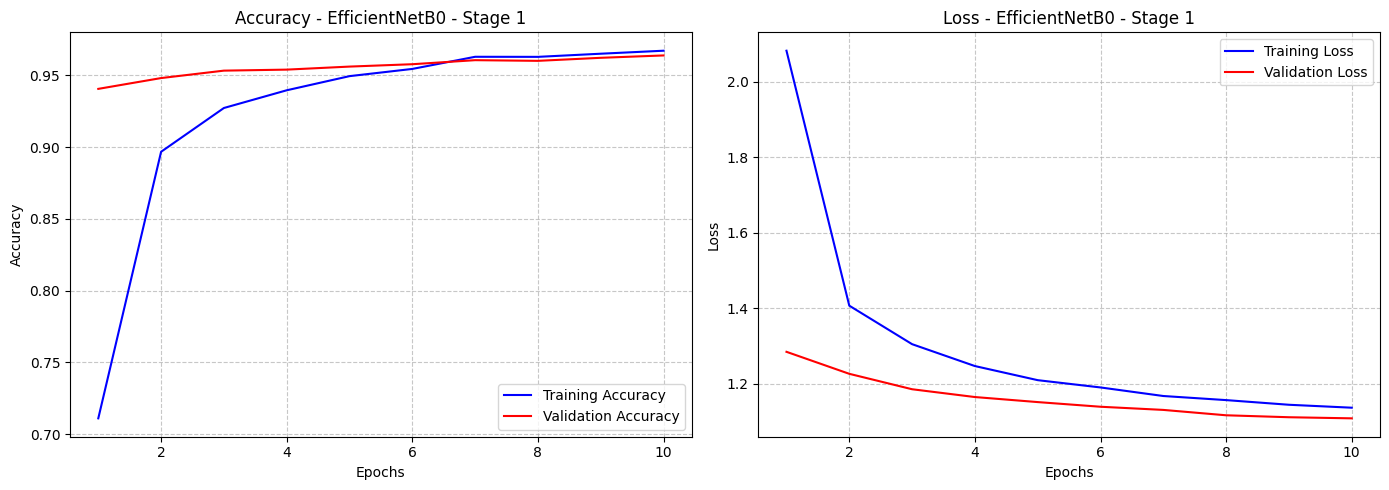

140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 164ms/step

--- EfficientNetB0 - Stage 1 ---
Accuracy : 96.02%
Precision: 0.9625
Recall   : 0.9606
F1-score : 0.9604


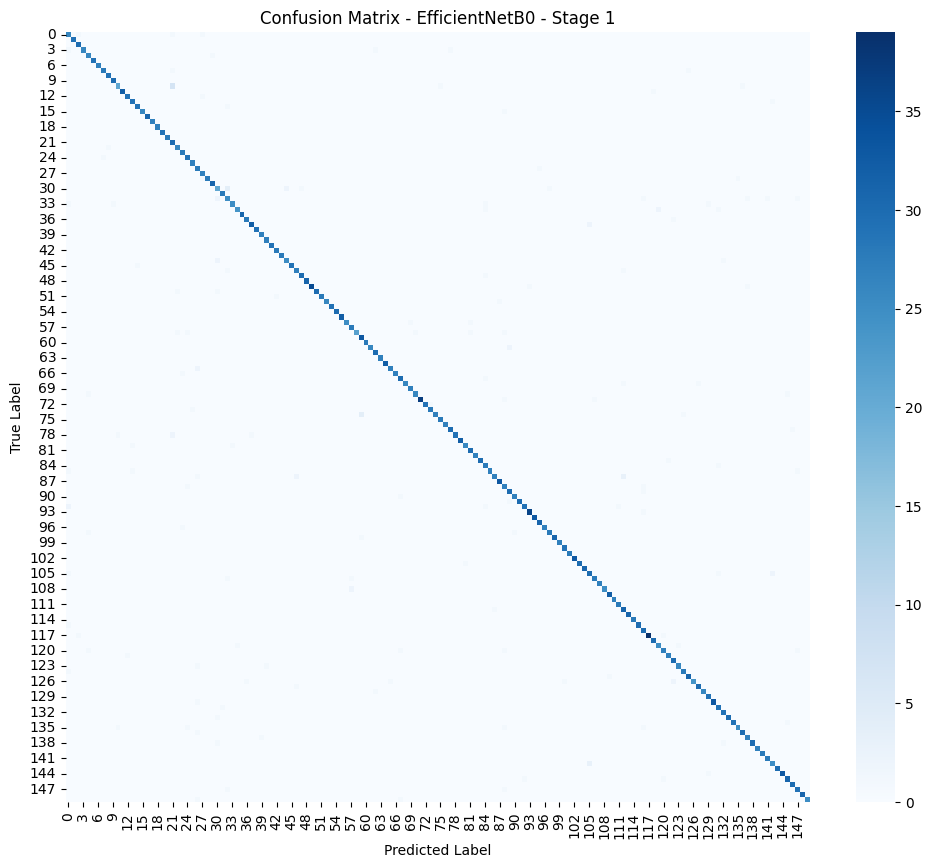

In [13]:
plot_training_history(history_stage1, title="EfficientNetB0 - Stage 1")
evaluate_and_plot(model_eff, test_gen, title="EfficientNetB0 - Stage 1")

## Fine-Tuning - Giai Đoạn 2 (Mở Khóa Backbone)

In [14]:
def unfreeze_layers_for_finetune(model, start_block='block7'):
    model.trainable = True

    set_trainable = False
    for layer in model.layers:
        if layer.name.startswith(start_block):
            set_trainable = True
        layer.trainable = set_trainable

    return model

In [15]:
early_stop_ft = EarlyStopping(monitor='val_loss', patience=3,
                               restore_best_weights=True, verbose=1)
reduce_lr_ft  = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                   patience=2, min_lr=1e-6, verbose=1)
callbacks_ft  = [early_stop_ft, reduce_lr_ft]

# Mở khóa block 7;
model_eff = unfreeze_layers_for_finetune(model_eff)

model_eff.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

print("\n[EfficientNetB0] Fine-Tuning - Giai đoạn 2 (Backbone Unfrozen)...")
history_ft = model_eff.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks_ft
)


[EfficientNetB0] Fine-Tuning - Giai đoạn 2 (Backbone Unfrozen)...
Epoch 1/15
628/628 ━━━━━━━━━━━━━━━━━━━━ 99s 112ms/step - accuracy: 0.8575 - loss: 1.5757 - val_accuracy: 0.9395 - val_loss: 1.2141 - learning_rate: 1.0000e-05
Epoch 2/15
628/628 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9185 - loss: 1.3304 - val_accuracy: 0.9548 - val_loss: 1.1575 - learning_rate: 1.0000e-05
Epoch 3/15
628/628 ━━━━━━━━━━━━━━━━━━━━ 84s 70ms/step - accuracy: 0.9409 - loss: 1.2384 - val_accuracy: 0.9581 - val_loss: 1.1406 - learning_rate: 1.0000e-05
Epoch 4/15
628/628 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.9533 - loss: 1.1906 - val_accuracy: 0.9612 - val_loss: 1.1345 - learning_rate: 1.0000e-05
Epoch 5/15
628/628 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.9614 - loss: 1.1651 - val_accuracy: 0.9642 - val_loss: 1.1291 - learning_rate: 1.0000e-05
Epoch 6/15
628/628 ━━━━━━━━━━━━━━━━━━━━ 48s 76ms/step - accuracy: 0.9658 - loss: 1.1485 - val_accuracy: 0.9652 - val_loss: 1.1248 - learning_r

### Kết Quả Fine-Tuning

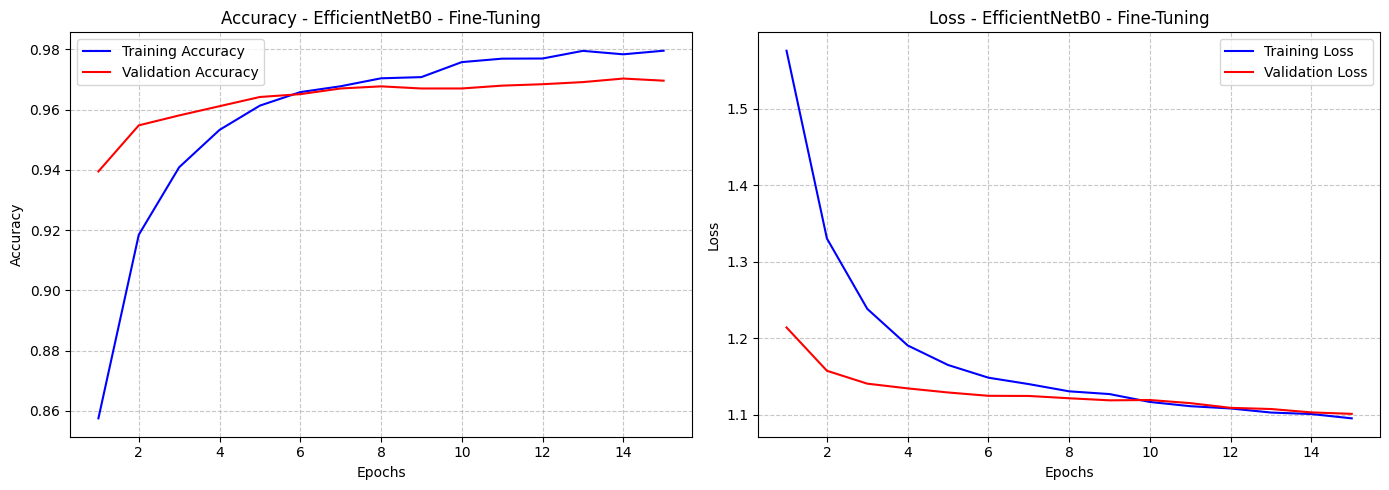

140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 113ms/step

--- EfficientNetB0 - Fine-Tuning ---
Accuracy : 96.55%
Precision: 0.9669
Recall   : 0.9657
F1-score : 0.9656


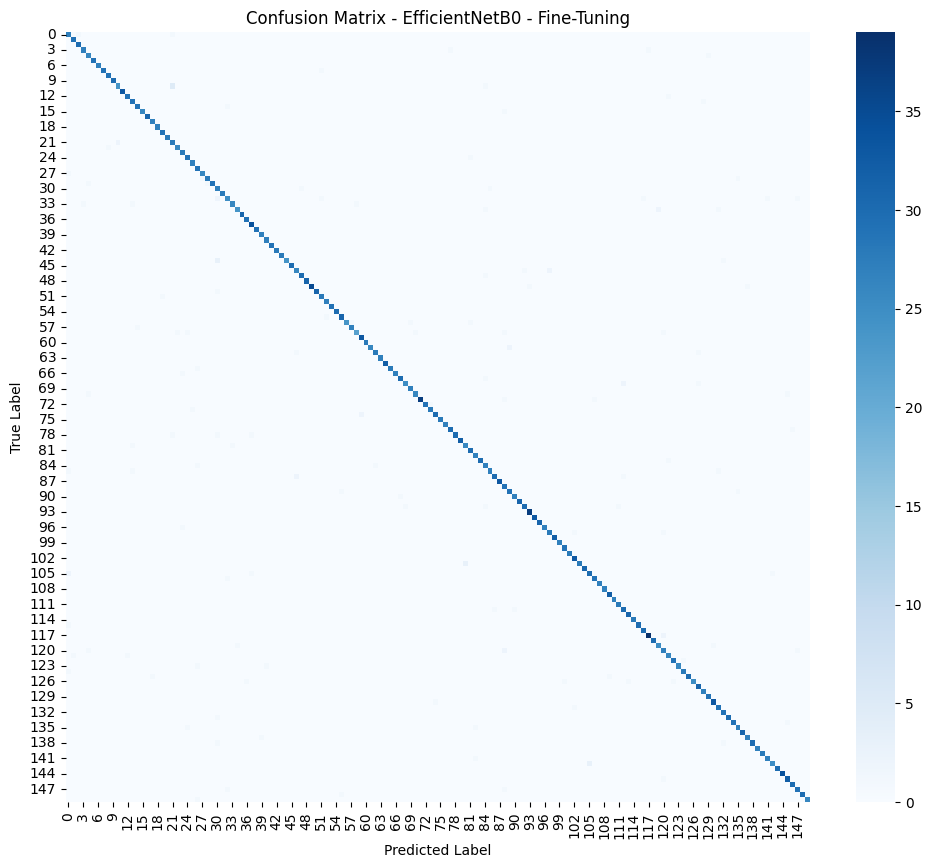

140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step


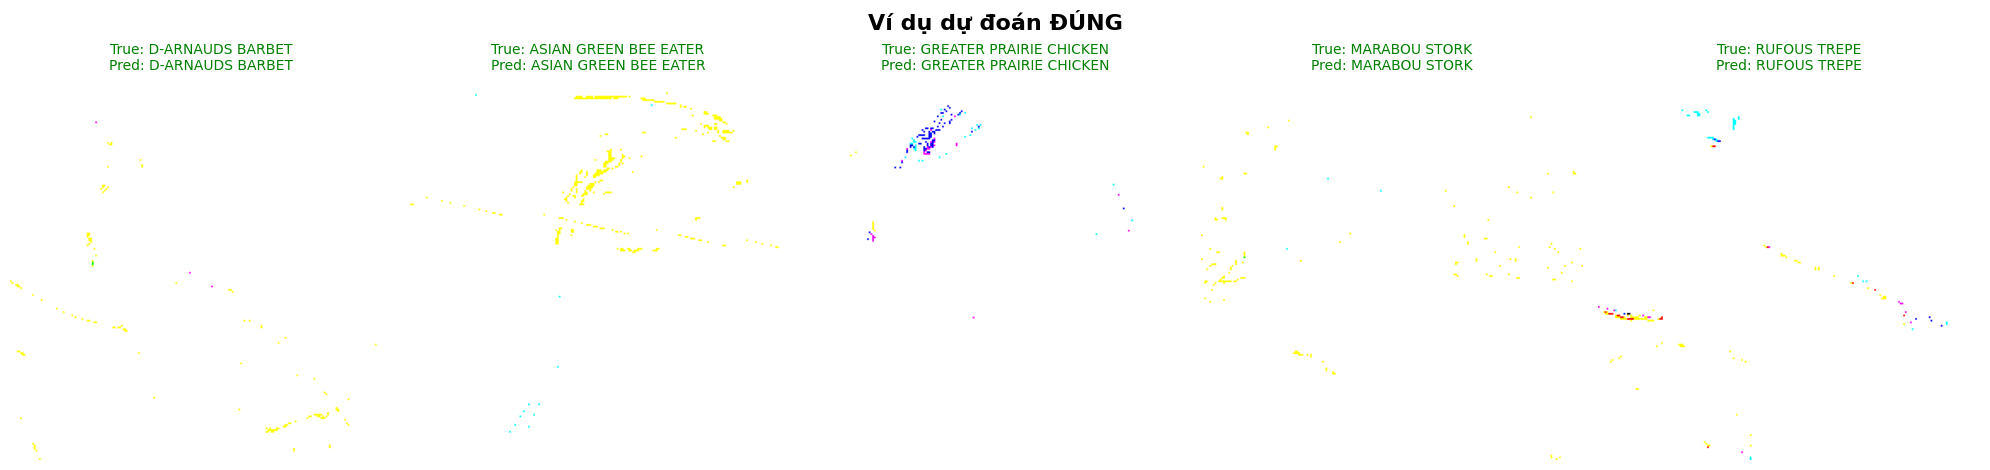

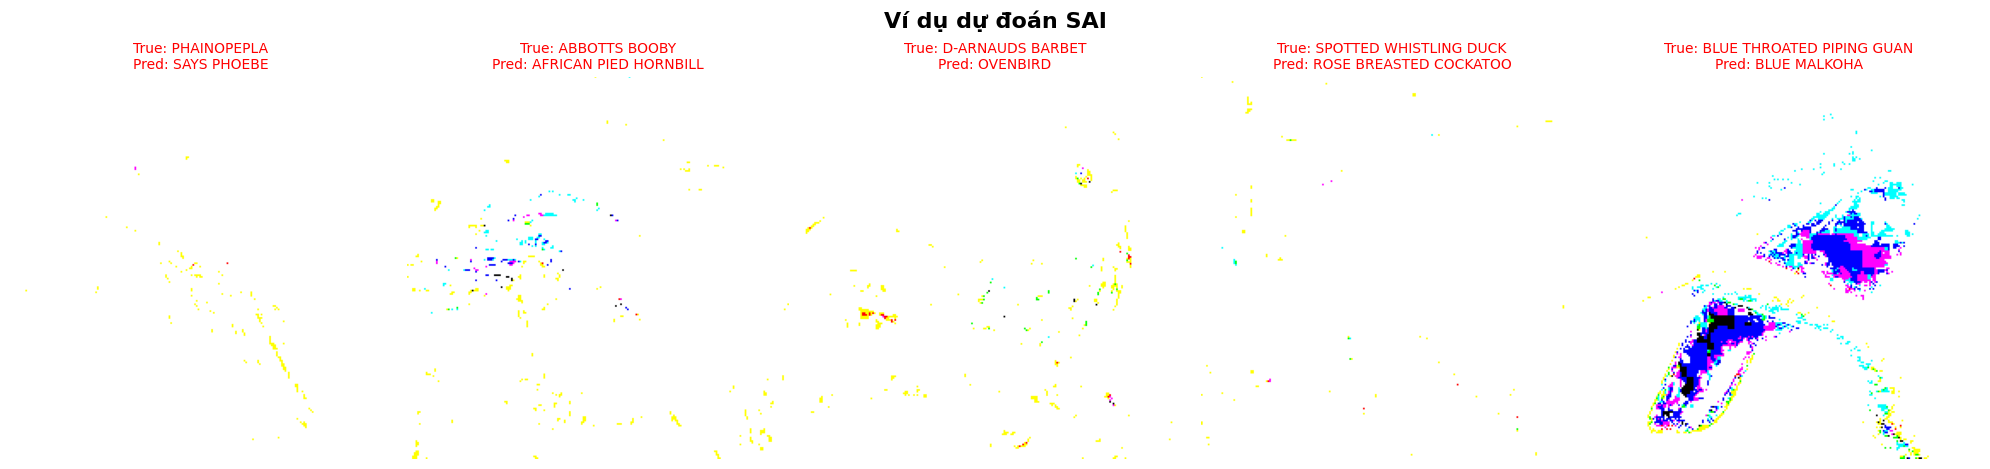

In [16]:
plot_training_history(history_ft, title="EfficientNetB0 - Fine-Tuning")
evaluate_and_plot(model_eff, test_gen, title="EfficientNetB0 - Fine-Tuning")
plot_sample_predictions(model_eff, test_gen, num_samples=5)